# 1. 神经网络

## （1） 神经网络介绍
神经网络中信息只向一个方向移动，即从输入节点向前移动，通过隐藏节点，再向输出节点移动。其中的基本部分是:

1. **输入层（Input Layer）**: 即输入x的那一层（如图像、文本、声音等）。每个输入特征对应一个神经元。输入层将数据传递给下一层的神经元。
2. **输出层（Output Layer）**: 即输出y的那一层。输出层的神经元根据网络的任务（回归、分类等）生成最终的预测结果。
3. **隐藏层（Hidden Layers）**: 输入层和输出层之间都是隐藏层，神经网络的“深度”通常由隐藏层的数量决定。隐藏层的神经元通过加权和激活函数处理输入，并将结果传递到下一层。

特点是：

- 同一层的神经元之间没有连接
- 第N层的每个神经元和第N-1层的所有神经元相连（这就是Fully Connected的含义)，这就是**全连接神经网络（FCNN）**
- 全连接神经网络接收的样本数据是**二维的**，数据在每一层之间需要以二维的形式传递
- 第N-1层神经元的输出就是第N层神经元的输入
- 每个连接都有一个权重值（w系数和b系数）

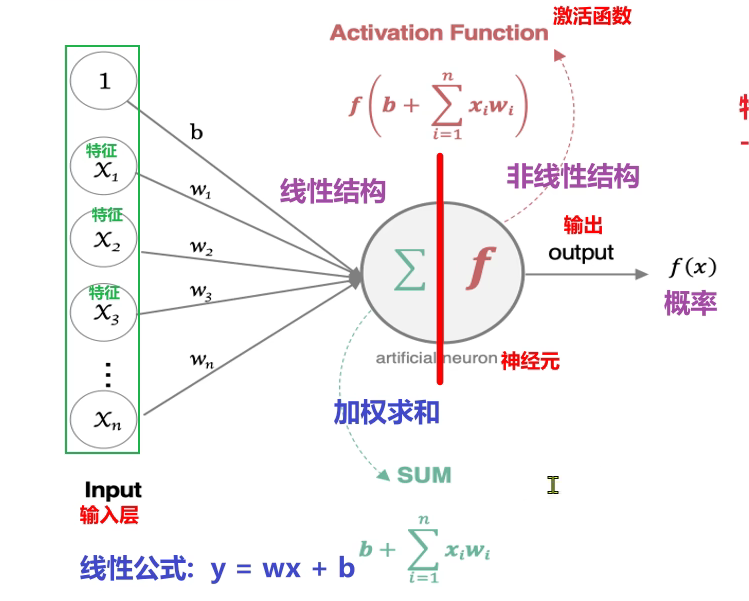
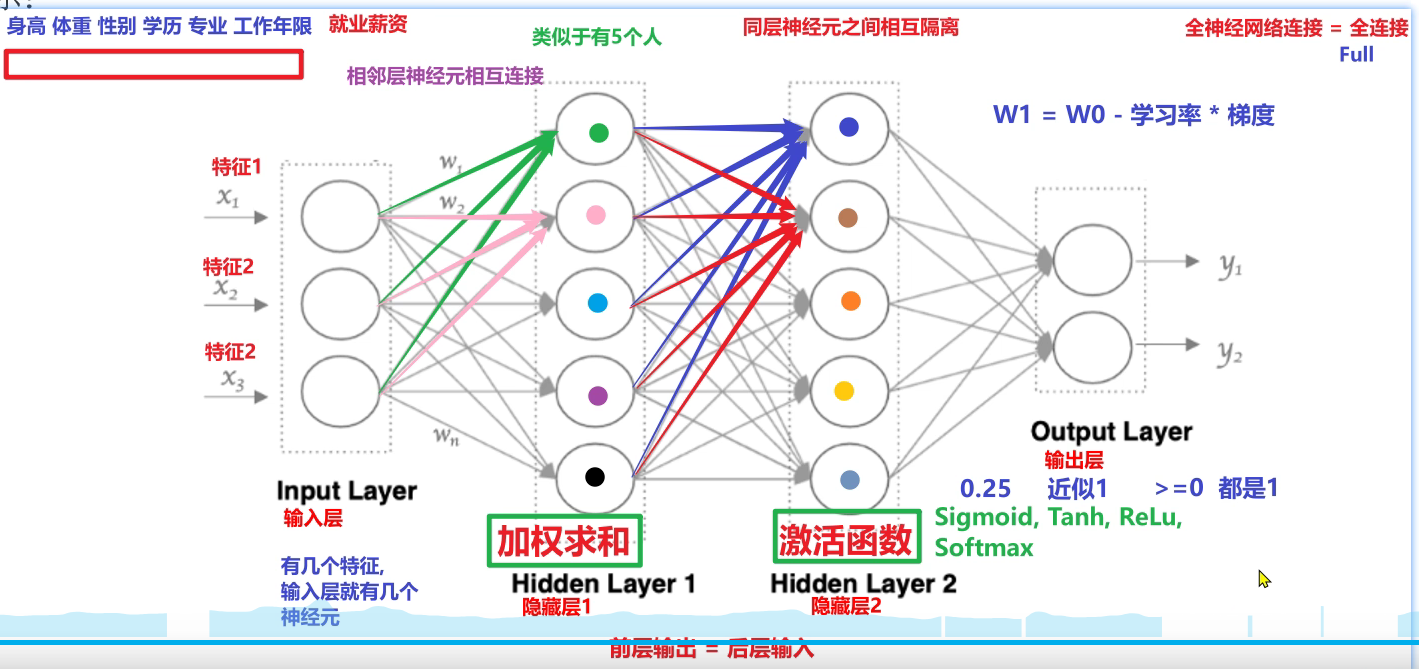
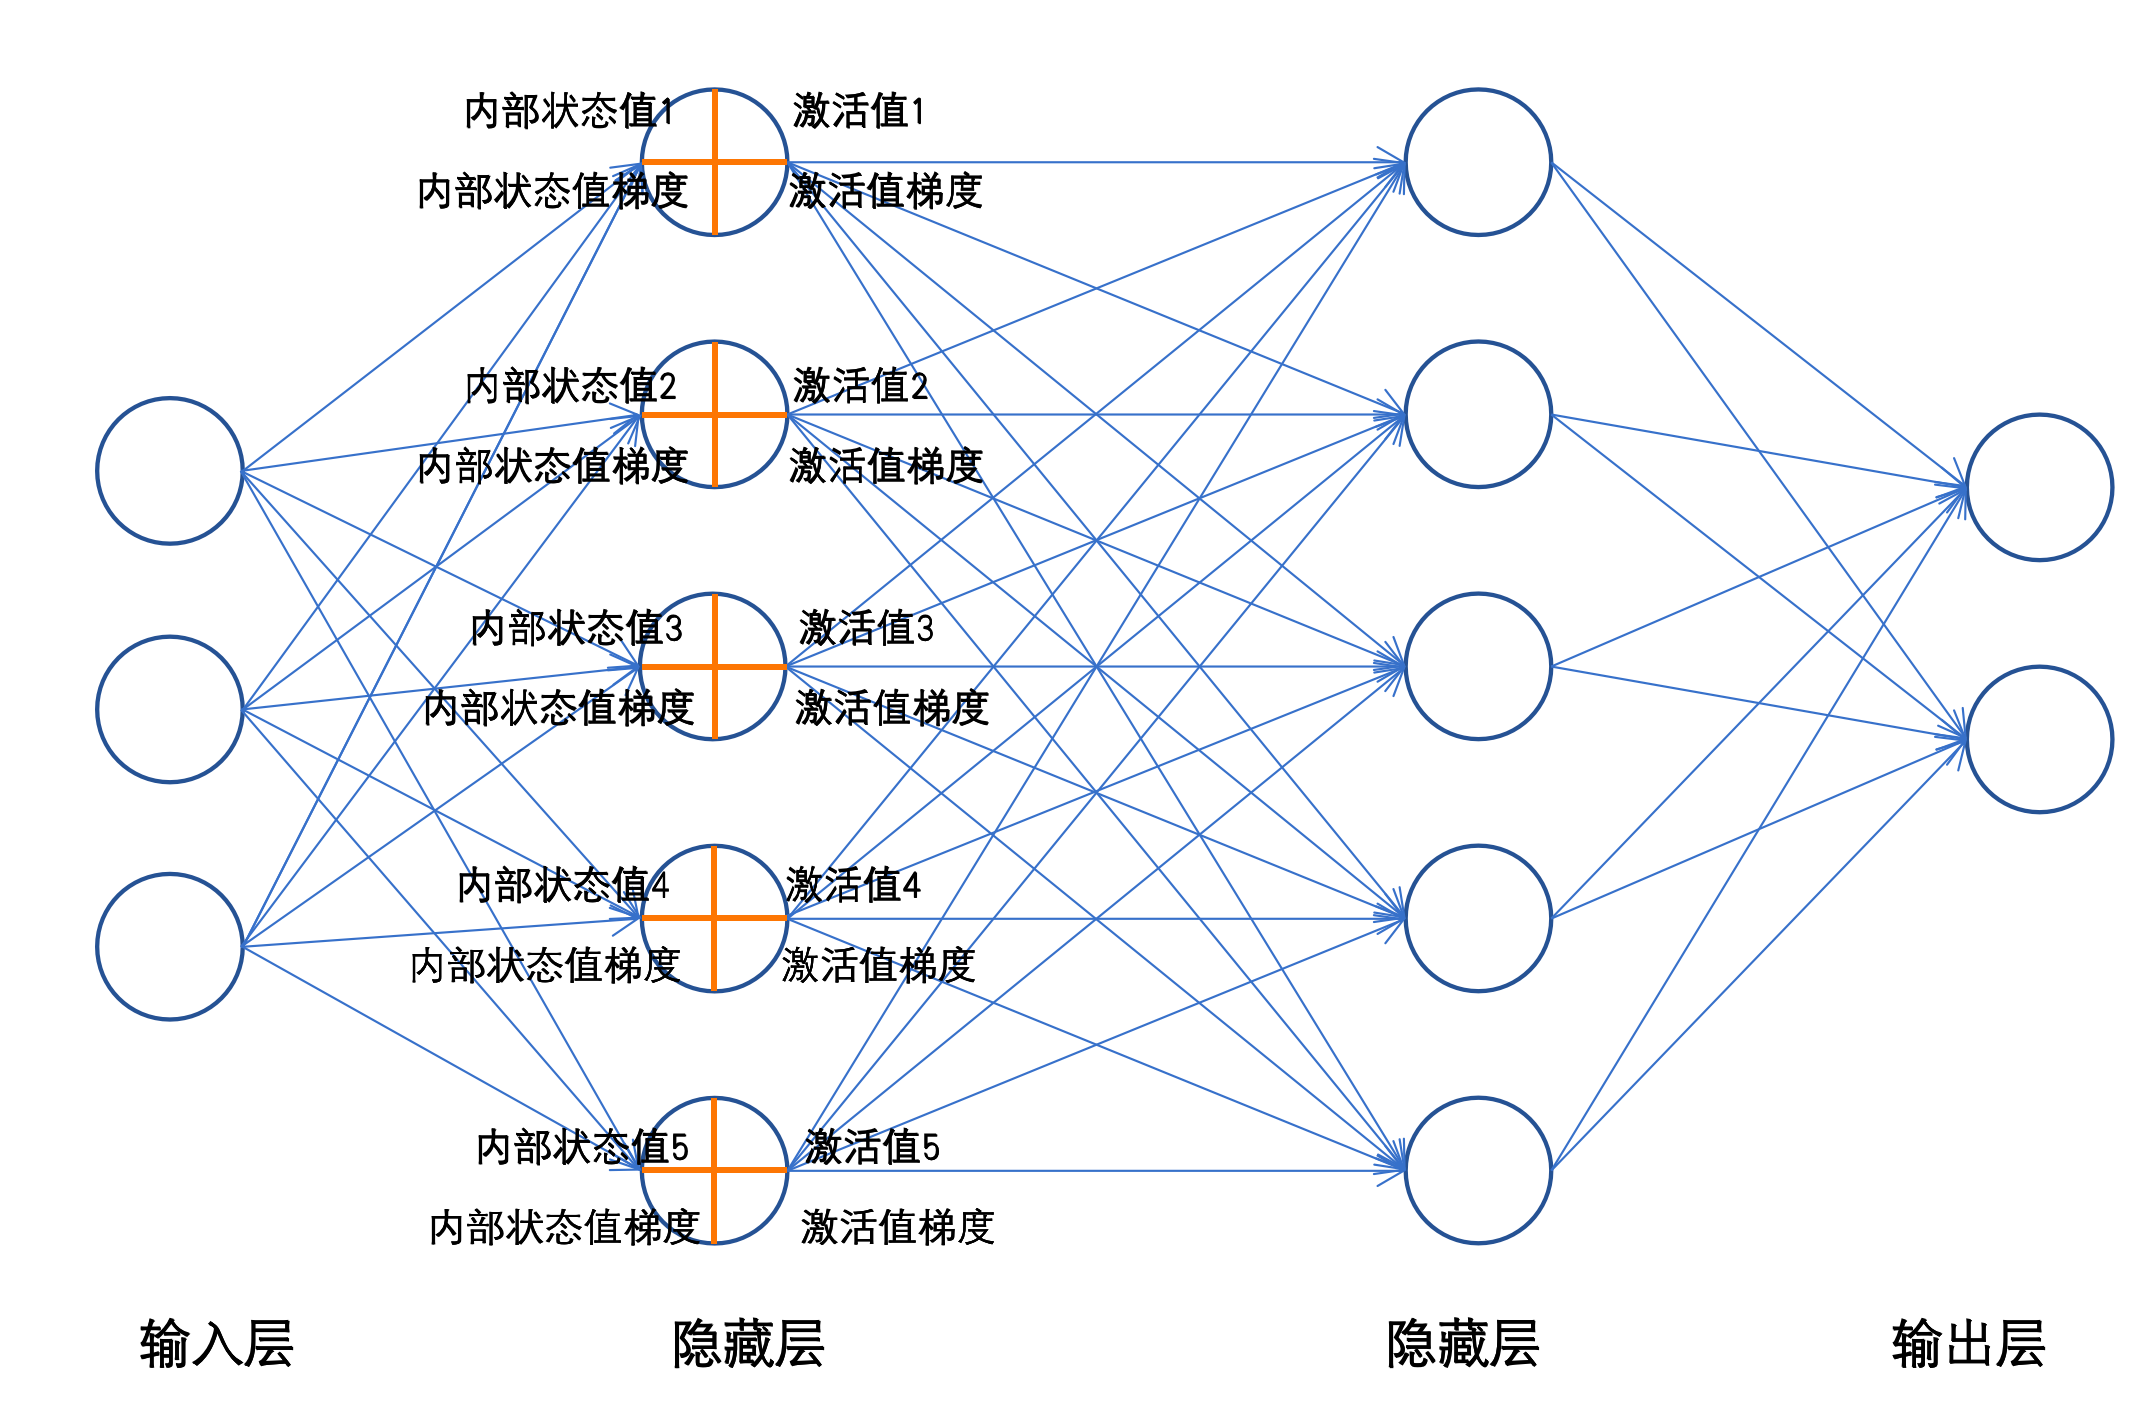

## （2）激活函数
用于对每层的输出数据进行变换，进而为整个网络注入了**非线性因素**。此时，神经网络就可以拟合各种曲线
- 没有引入非线性因素的网络等价于使用一个线性模型来拟合
- 通过给网络输出增加激活函数，实现引入非线性因素，使得网络模型可以逼近任意函数，提升网络对复杂问题的拟合能力。

### （2.1）Sigmoid 激活函数

公式：

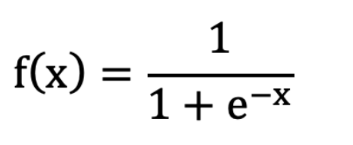

求导：

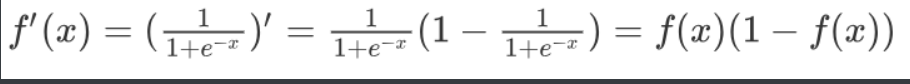

图像：

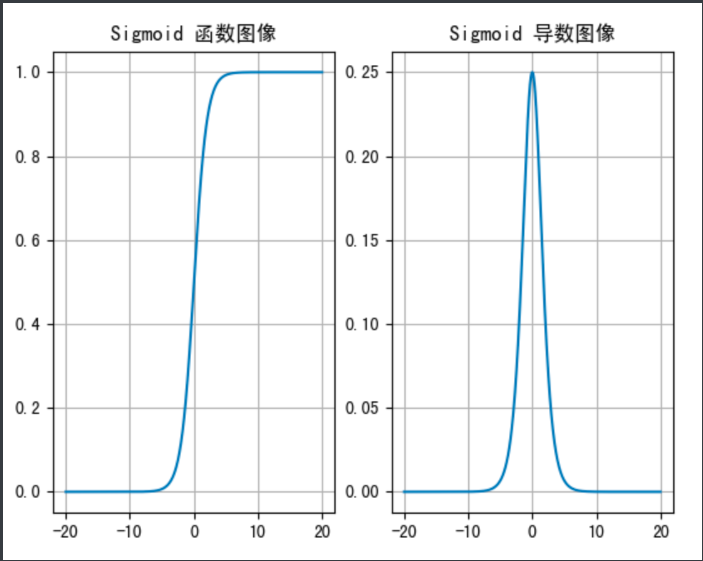


- 从sigmoid函数图像可以得到，sigmoid 函数可以将**任意的输入**映射到 **(0, 1)** 之间，当输入的值大致在**&lt;-6或者&gt;6**时，意味着输入任何值得到的激活值都是差不多的，这样会丢失部分的信息。比如：输入100和输入10000经过 sigmoid的激活值几乎都是等于1的，但是输入的数据之间相差100倍的信息就丢失了。

- 对于sigmoid函数而言，输入值在**[-6, 6]**之间输出值才会**有明显差异**，输入值在**[-3, 3]**之间才会**有比较好的效果**

- 通过上述导数图像，我们发现**导数数值范围是 (0, 0.25)**，当输入的值**&lt;-6或者&gt;6**时，sigmoid激活函数图像的**导数接近为 0**，此时**网络参数将更新极其缓慢，或者无法更新。**

- 一般来说，sigmoid网络在**5层之内**就会产生**梯度消失**现象。而且，该激活函数的激活值并不是以0为中心的，激活值总是偏向正数，导致梯度更新时，只会对某些特征产生相同方向的影响，所以在实践中这种激活函数使用的很少。**sigmoid函数一般只用于二分类的输出层**。

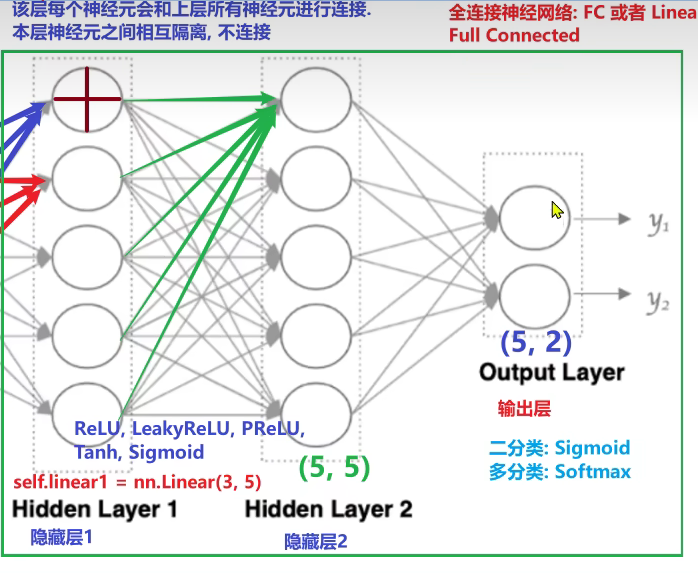

In [3]:
import torch 
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

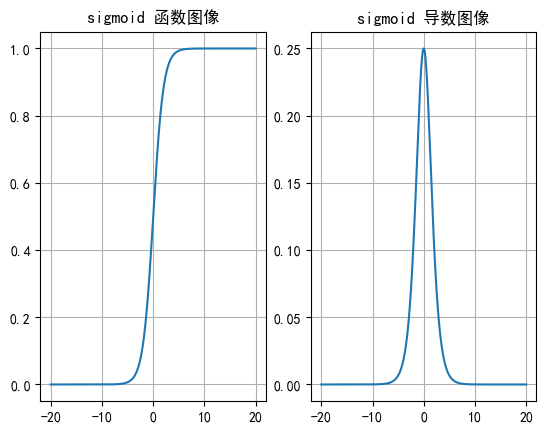

In [12]:
# 创建画布和坐标轴
_, axes = plt.subplots(1, 2)

# 函数图像
x = torch.linspace(-20, 20, 1000)

# 输入值 x 通过 sigmoid 函数转换乘激活值 y 
y = torch.sigmoid(x)
axes[0].plot(x.numpy(),y)
axes[0].grid()
axes[0].set_title('sigmoid 函数图像')

# 导数图像
x  = torch.linspace(-20, 20, 1000, requires_grad=True)
torch.sigmoid(x).sum().backward()

# x.detach(): 输入值 x 的 ndarray 数组
# x.grad : 计算梯度，求导
axes[1].plot(x.detach(), x.grad)
axes[1].grid()
axes[1].set_title('sigmoid 导数图像')

plt.show()

### （2.2） Tanh 函数
Tanh叫做双曲正切函数，公式: 
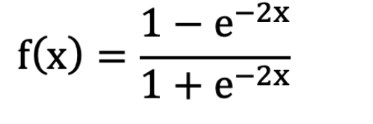

求导公式: 
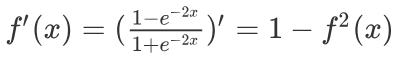

图像： 
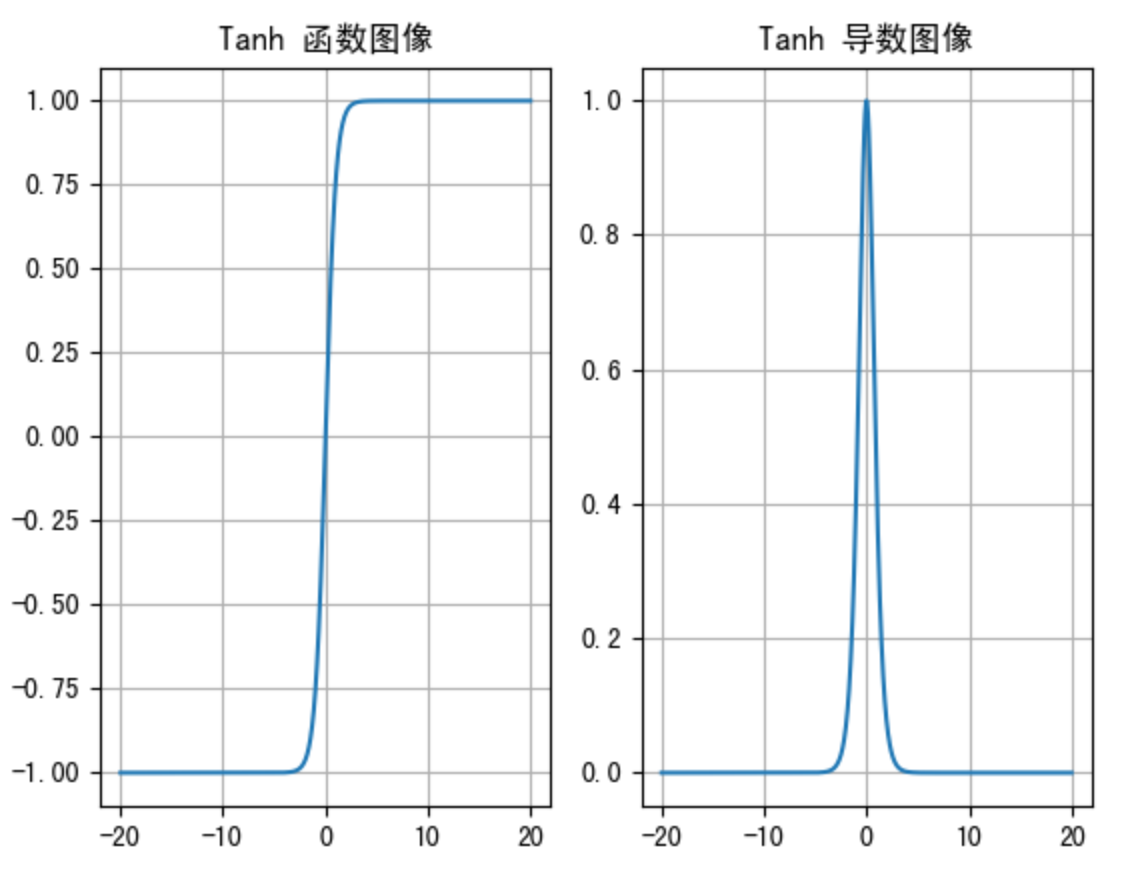

- 由上面的函数图像可以看到，Tanh函数将**输入映射到(-1, 1)之间**，图像以0为中心，激活值在0点对称，当输入的值大概&lt;-3或者&gt;3 时将被映射为-1或者1。**其导数值范围 (0, 1)**，当输入的值大概&lt;-3或者&gt;3时，其导数近似0。

- 与Sigmoid相比，它是**以0为中心的**，使得其收敛速度要比Sigmoid快，减少迭代次数。然而，从图中可以看出，Tanh两侧的导数也为0，同样会造成梯度消失。

- 若使用时可在**隐藏层使用tanh函数**，在**输出层使用sigmoid函数**，且适用于浅层神经网络（不超过5层），较之于sigmoid，收敛速度快。

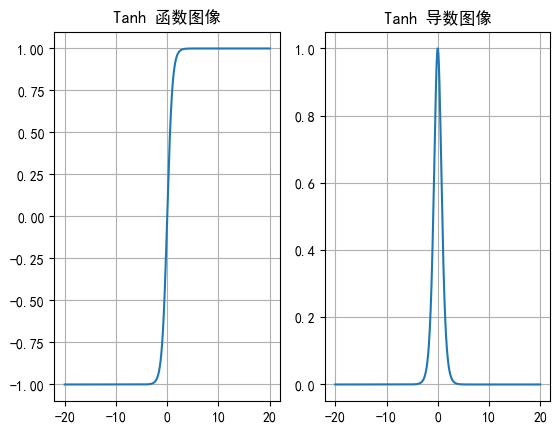

In [13]:
# 创建画布和坐标轴
_, axes = plt.subplots(1, 2)

# 函数图像
x = torch.linspace(-20, 20, 1000)

# 输入值 x 通过 Tanh 函数转换乘激活值 y 
y = torch.tanh(x)
axes[0].plot(x.numpy(),y)
axes[0].grid()
axes[0].set_title('Tanh 函数图像')

# 导数图像
x  = torch.linspace(-20, 20, 1000, requires_grad=True)
torch.tanh(x).sum().backward()

# x.detach(): 输入值 x 的 ndarray 数组
# x.grad : 计算梯度，求导
axes[1].plot(x.detach(), x.grad)
axes[1].grid()
axes[1].set_title('Tanh 导数图像')

plt.show()

### (2.3)  ReLU 激活函数
ReLU 激活函数公式如下：（默认情况下只考虑正样本）
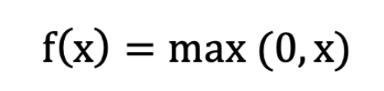

激活函数求导公式: 
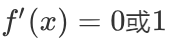

图像：
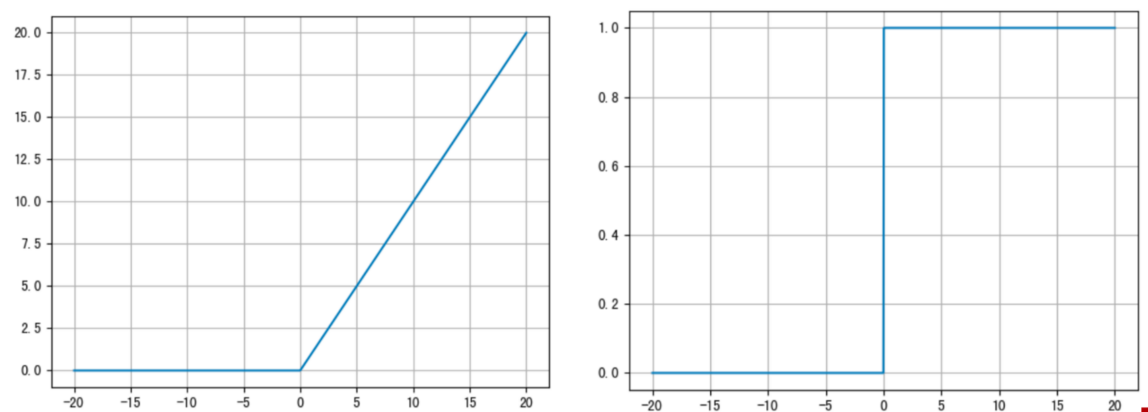

- ReLU 激活函数将小于0的值映射为0，而大于0的值则保持不变，它更加重视正信号，而忽略负信号，这种激活函数运算更为简单，能够提高模型的训练效率。
- 当x<0时，ReLU导数为0，而当x>0时，则不存在饱和问题。所以，ReLU 能够在x>0时保持梯度不衰减，从而缓解梯度消失问题。然而，随着训练的推进，部分输入会落入小于0区域，导致对应权重无法更新。这种现象被称为“神经元死亡”。
- ReLU是目前==最常用的激活函数==。与sigmoid相比，RELU的优势是：
  - 采用sigmoid函数，计算量大（指数运算），反向传播求误差梯度时，计算量相对大；而采用Relu激活函数，整个过程的计算量节省很多 
  - sigmoid函数反向传播时，很容易就会出现梯度消失的情况，从而无法完成深层网络的训练；而采用relu激活函数，当输入的值>0时，梯度为1，不会出现梯度消失的情况 
  - Relu会使一部分神经元的输出为0，这样就造成了网络的稀疏性，并且减少了参数的相互依存关系，缓解了过拟合问题的发生

### （2.4）softmax 激活函数
softmax用于**多分类**过程中，它是二分类函数sigmoid在多分类上的推广，目的是**将多分类的结果以概率的形式展现出来**。
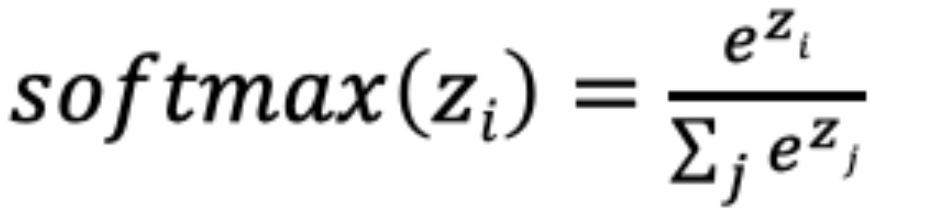

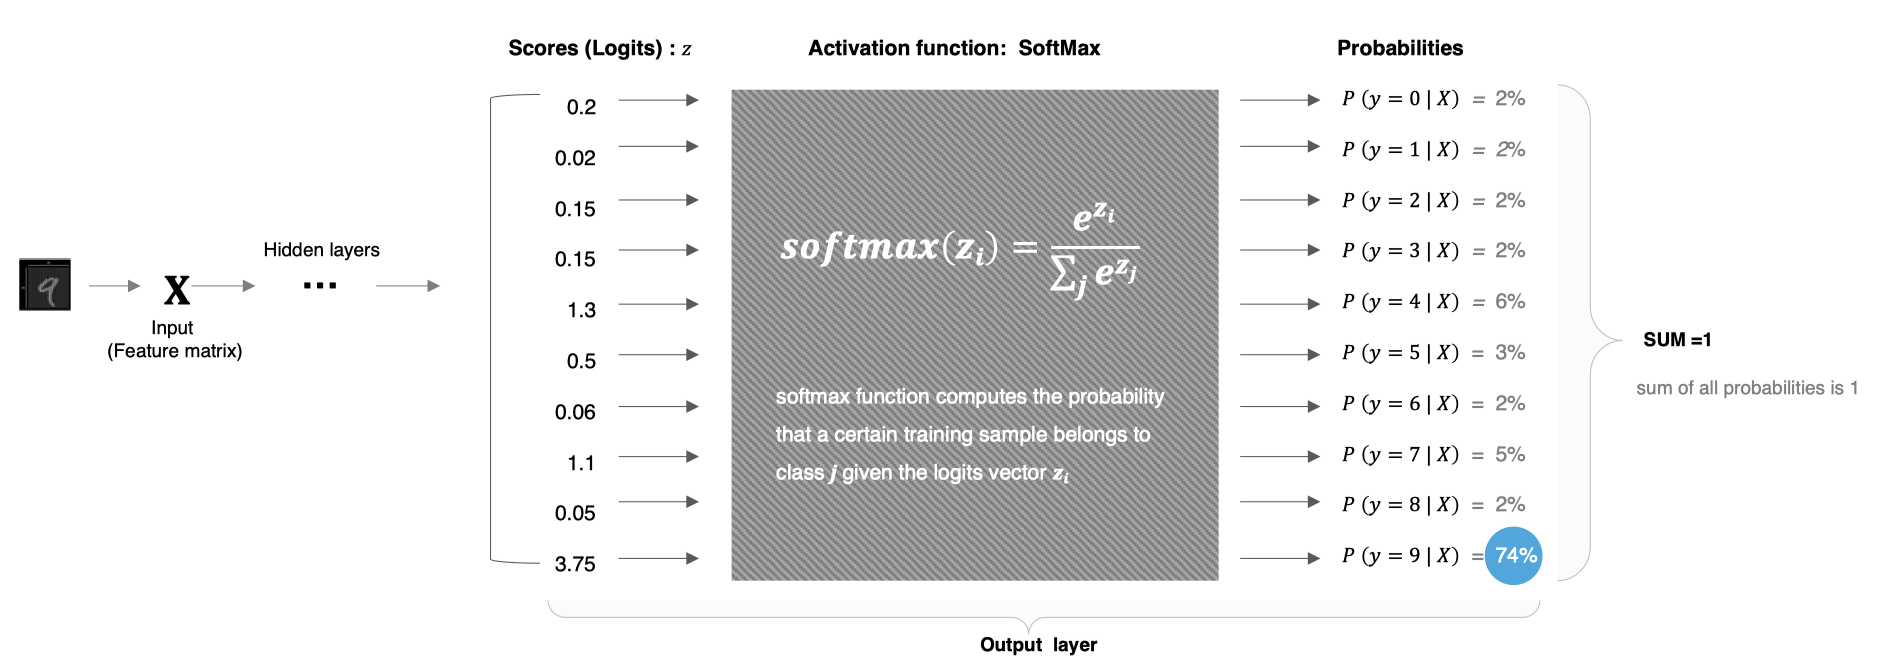

SoftMax就是将网络输出的logits通过softmax函数，映射成为(0,1)的值，而这些值的累和为1（满足概率的性质），那么我们将它理解成概率，选取概率最大（也就是值对应最大的）节点，作为我们的预测目标类别。 

In [14]:
scores = torch.tensor([0.2, 0.02, 0.15, 0.15, 1.3, 0.5, 0.06, 1.1, 0.05, 3.75])
# dim=0, 按行计算
probabilities = torch.softmax(scores, dim=0)
print(probabilities)

tensor([0.0212, 0.0177, 0.0202, 0.0202, 0.0638, 0.0287, 0.0185, 0.0522, 0.0183,
        0.7392])


### （2.5） 激活函数的选择方法
对于**隐藏层**:

1. 优先选择ReLU激活函数
2. 如果ReLu效果不好，那么尝试其他激活，如Leaky ReLu等。
3. 如果你使用了ReLU， 需要注意一下Dead ReLU问题，避免出现0梯度从而导致过多的神经元死亡。
4. 少使用sigmoid激活函数，可以尝试使用tanh激活函数

对于**输出层**:

1. 二分类问题选择sigmoid激活函数
2. 多分类问题选择softmax激活函数
3. 回归问题选择identity激活函数

## (3) 参数初始化
我们在构建网络之后，网络中的参数是需要初始化的。我们需要初始化的参数主要有**权重**和**偏置**，**偏置一般初始化为0即可**，而对权重的初始化则会更加重要。

参数初始化的作用：

- **防止梯度消失或爆炸**：初始权重值过大或过小会导致梯度在反向传播中指数级增大或缩小。
- **提高收敛速度**：合理的初始化使得网络的激活值分布适中，有助于梯度高效更新。
- **保持对称性破除**：权重的初始化需要打破对称性，否则网络的学习能力会受到限制。

参数初始化的方式： 
- 无法打破对称性的：
  > 全0， 全1， 固定值
- 可以打破对称性的：
  > 随机初始化， 正态分布初始化， kaiming初始化，xavier 初始化


1. 记忆 kaiming初始化， xavier初始化，全0初始化
2. 关于初始化的选择上：
   - 激活函数 ReLU及其系列：优先用 kaiming
   - 激活函数非 ReLU: 优先用 xavier
   - 如果是浅层网络，可以考虑使用随机初始化

In [1]:
import torch.nn as nn 

# 2. 损失函数

# 3. 网络优化方法

# 4. 正则化方法

# 5. 案例——价格分类案例